## Code to generate figure for cell types by organ by crosswalk/tool

## Install and import libraries

In [1]:
%pip install requests pandas seaborn matplotlib

import requests
import pandas as pd
from io import StringIO
import io
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# warnings
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Functions

In [2]:
def load_crosswalk(url: str, source: str):
    df = pd.read_csv(url, skiprows=10)
    df["source"] = source
    return df

In [3]:
def get_label(uberon_id):
    iri = f'http://purl.obolibrary.org/obo/{uberon_id.replace(":", "_")}'
    url = "https://www.ebi.ac.uk/ols4/api/ontologies/uberon/terms"
    resp = requests.get(url, params={"iri": iri})
    if resp.status_code == 200 and resp.json()["_embedded"]["terms"]:
        return resp.json()["_embedded"]["terms"][0]["label"]
    return None

## Get data

In [4]:
df_azimuth = load_crosswalk(
    "https://cdn.humanatlas.io/digital-objects/ctann/azimuth/v1.3/assets/azimuth-crosswalk.csv", "azimuth"
)

df_celltypist = load_crosswalk(
    "https://cdn.humanatlas.io/digital-objects/ctann/celltypist/v1.2/assets/celltypist-crosswalk.csv",
    "celltypist",
)


df_popv = load_crosswalk(
    "https://cdn.humanatlas.io/digital-objects/ctann/popv/v1.3/assets/popv-crosswalk.csv",
    "popv",
)

df_pan_human_azimuth = load_crosswalk(
    "https://cdn.humanatlas.io/digital-objects/ctann/pan-human-azimuth/v1.1/assets/pan-human-azimuth-crosswalk.csv",
    "pan_human_azimuth",
)


df_fr_match = load_crosswalk(
    "https://cdn.humanatlas.io/digital-objects/ctann/frmatch/v1.0/assets/frmatch-crosswalk.csv",
    "fr_match",
)

df_combined = pd.concat([df_azimuth, df_celltypist, df_popv, df_pan_human_azimuth, df_fr_match])
df_combined

,Organ_Level,Organ_ID,Annotation_Label,Annotation_Label_ID,CL_Label,CL_ID,CL_Match,source
0,Heart_L2,UBERON:0000948,Adipocyte,AZ:0000001,adipocyte,CL:0000136,skos:exactMatch,azimuth
1,Heart_L2,UBERON:0000948,Arterial Endothelial,AZ:0000002,endothelial cell of artery,CL:1000413,skos:exactMatch,azimuth
2,Heart_L2,UBERON:0000948,Atrial Cardiomyocyte,AZ:0000003,regular atrial cardiac myocyte,CL:0002129,skos:exactMatch,azimuth
3,Heart_L2,UBERON:0000948,B,AZ:0000004,B cell,CL:0000236,skos:exactMatch,azimuth
4,Heart_L2,UBERON:0000948,Capillary Endothelial,AZ:0000005,capillary endothelial cell,CL:0002144,skos:exactMatch,azimuth
...,...,...,...,...,...,...,...,...
64,lung,UBERON:0002048,Smooth muscle FAM83D+,FR:0000065,smooth muscle cell:FAM83D+,CL:0000192,skos:narrowMatch,fr_match
65,lung,UBERON:0002048,Subpleural fibroblasts,FR:0000066,fibroblast:subpleural,CL:0000057,skos:narrowMatch,fr_match
66,lung,UBERON:0002048,Suprabasal,FR:0000067,respiratory suprabasal cell,CL:4033048,skos:exactMatch,fr_match
67,lung,UBERON:0002048,T cells proliferating,FR:0000068,T cell:proliferating,CL:0000084,skos:narrowMatch,fr_match


## Preprocess

In [5]:
# get nunique() cell_label by tool per as_label by sex
df_counts = (
    df_combined.groupby(["source", "Organ_ID"])["CL_Label"]
    .nunique()
    .reset_index(name="n_unique_cell_label")
)

df_counts

,source,Organ_ID,n_unique_cell_label
0,azimuth,UBERON:0000178,77
1,azimuth,UBERON:0000948,24
2,azimuth,UBERON:0001013,55
3,azimuth,UBERON:0001264,13
4,azimuth,UBERON:0001347,55
5,azimuth,UBERON:0001384,19
6,azimuth,UBERON:0002048,100
7,azimuth,UBERON:0002107,27
8,azimuth,UBERON:0002113,57
9,azimuth,UBERON:0002371,46


In [6]:
df_counts["source"] = df_counts["source"].map(
    {
        "azimuth": "Azimuth",
        "celltypist": "CellTypist",
        "popv": "popV",
        "fr_match": "FR-Match",
        "pan_human_azimuth": "Pan-Human Azimuth"
    }
)

In [7]:
df_counts["organ_label"] = df_counts["Organ_ID"].apply(get_label)
df_counts

,source,Organ_ID,n_unique_cell_label,organ_label
0,Azimuth,UBERON:0000178,77,blood
1,Azimuth,UBERON:0000948,24,heart
2,Azimuth,UBERON:0001013,55,adipose tissue
3,Azimuth,UBERON:0001264,13,pancreas
4,Azimuth,UBERON:0001347,55,white adipose tissue
5,Azimuth,UBERON:0001384,19,primary motor cortex
6,Azimuth,UBERON:0002048,100,lung
7,Azimuth,UBERON:0002107,27,liver
8,Azimuth,UBERON:0002113,57,kidney
9,Azimuth,UBERON:0002371,46,bone marrow


## Get counts

In [30]:
result = (
    df_combined.loc[df_combined["source"].isin(["azimuth", "celltypist", "popv"])]
    .groupby("source", as_index=False)["CL_Label"]
    .nunique()
)

# Add total row (ALL unique CTs across the filtered data)
total_row = {
    "source": "ALL",
    "CL_Label": df_combined.loc[
        df_combined["source"].isin(["azimuth", "celltypist", "popv"]), "CL_Label"
    ].nunique(),
}

result = pd.concat([result, pd.DataFrame([total_row])], ignore_index=True)

result

,source,CL_Label
0,azimuth,422
1,celltypist,425
2,popv,149
3,ALL,774


In [31]:
result = (
    df_combined.loc[df_combined["source"].isin(["azimuth", "celltypist", "popv"])]
    .groupby("source", as_index=False)["Organ_ID"]
    .nunique()
)

# Add total row (ALL unique Organ_ID across the filtered data)
total_row = {
    "source": "ALL",
    "Organ_ID": df_combined.loc[
        df_combined["source"].isin(["azimuth", "celltypist", "popv"]), "Organ_ID"
    ].nunique(),
}

result = pd.concat([result, pd.DataFrame([total_row])], ignore_index=True)

result

,source,Organ_ID
0,azimuth,11
1,celltypist,16
2,popv,24
3,ALL,32


## Visualize

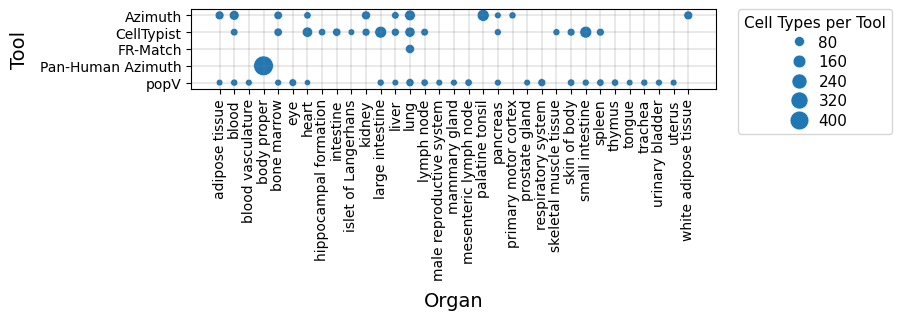

In [8]:
# Ensure the df is stringy and sorted
order = sorted(df_counts["organ_label"].astype(str).unique())

df_counts["organ_label"] = pd.Categorical(
    df_counts["organ_label"].astype(str), categories=order, ordered=True
)

# Create the scatter graph
g = sns.scatterplot(
    data=df_counts,
    x="organ_label",
    y="source",
    size="n_unique_cell_label",
    sizes=(20, 200),
    legend="brief",
)

# # Set white background for figure and axes
g.figure.set_facecolor("white")
g.set_facecolor("white")

# # Set thin grey grid lines
g.grid(True, which="major", axis="both", linestyle="-", linewidth=0.25, color="grey")

# # increase figure size to accommodate facet grid
g.figure.set_size_inches(10, 3.5)

# # Adjust spacing on x / Add vertical padding
g.margins(x=0.06)
g.margins(y=0.09)

# # Customize the plot
plt.xlabel("Organ", labelpad=8, fontsize=14)
plt.ylabel("Tool", labelpad=8, fontsize=14)

# # Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)

# # adjust legend
legend = g.legend(
    title="Cell Types per Tool",
    loc="upper right",
    labelspacing=0.3,
    fontsize=11,
    title_fontsize=11,
    bbox_to_anchor=(1.35, 1.1),
    handletextpad=0.3,
)

plt.tight_layout()

plt.show()